In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
import kagglehub
path = kagglehub.dataset_download("labbaxmx/opportunity-har")
print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
try:
    data = np.load(FILE_PATH, allow_pickle=True)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{FILE_PATH}'. "
        "Please check the filename and make sure it's in the same folder as this script."
    )

In [4]:
print("=" * 55)
print("  ACCELEROMETER DATASET — AT A GLANCE")
print("=" * 55)

# Dimensions
n_windows, n_features = data.shape
print(f"  📦 Shape          : {n_windows:,} rows × {n_features} columns")
print(f"  🔢 Data type      : {data.dtype}")

# Value range
data_min, data_max = data.min(), data.max()
print(f"  📊 Value range    : [{data_min:.4f}, {data_max:.4f}]")

# Data quality check
missing_count = np.isnan(data).sum()
if missing_count == 0:
    print(f"  ✅ Missing values : None — data is clean!")
else:
    print(f"  ⚠️  Missing values : {missing_count:,} ({100*missing_count/data.size:.2f}%)")

print("=" * 55)


  ACCELEROMETER DATASET — AT A GLANCE
  📦 Shape          : 11,771 rows × 453 columns
  🔢 Data type      : float64
  📊 Value range    : [-19.5811, 19.5811]
  ✅ Missing values : None — data is clean!


In [5]:
# ── Derived constants ─────────────────────────────────────────────────────────
N_WINDOWS   = data.shape[0]          # 11 771
N_FEATURES  = data.shape[1]          # 453
N_AXES      = 3                      # X, Y, Z
WINDOW_LEN  = N_FEATURES // N_AXES   # 151 samples per axis per window
ASSUMED_HZ  = 50                     # most common HAR sampling rate; adjust if known
WINDOW_SEC  = WINDOW_LEN / ASSUMED_HZ

# ── Axis slices ───────────────────────────────────────────────────────────────
X = data[:, :WINDOW_LEN]
Y = data[:, WINDOW_LEN:2*WINDOW_LEN]
Z = data[:, 2*WINDOW_LEN:]

metadata = {
    "No. of Subjects"  : "Not specified",
    "Activities"       : "Not specified",
    "Sensors Used"     : "Accelerometer (3-axis)",
    "Sensor Placement" : "Not specified",
    "Data Rate (Hz)"   : f"Not specified (assumed {ASSUMED_HZ} Hz)",
    "Window Size"      : f"{WINDOW_LEN} samples (~{WINDOW_SEC:.2f} sec at {ASSUMED_HZ} Hz)",
    "Overlap"          : "Not specified",
}

print("\n📋  DATASET METADATA SUMMARY")
print("-" * 55)
for k, v in metadata.items():
    print(f"  {k:<22}: {v}")
print("-" * 55)

print("\n📊  DERIVED STATISTICS")
print("-" * 55)
print(f"  Total windows             : {N_WINDOWS:,}")
print(f"  Samples per window (axis) : {WINDOW_LEN}")
print(f"  Feature columns           : {N_FEATURES}  (= {N_AXES} axes × {WINDOW_LEN} steps)")
print(f"  Est. total duration       : {N_WINDOWS * WINDOW_SEC / 3600:.2f} hrs  (0 % overlap assumed)")
print("-" * 55)


📋  DATASET METADATA SUMMARY
-------------------------------------------------------
  No. of Subjects       : Not specified
  Activities            : Not specified
  Sensors Used          : Accelerometer (3-axis)
  Sensor Placement      : Not specified
  Data Rate (Hz)        : Not specified (assumed 50 Hz)
  Window Size           : 151 samples (~3.02 sec at 50 Hz)
  Overlap               : Not specified
-------------------------------------------------------

📊  DERIVED STATISTICS
-------------------------------------------------------
  Total windows             : 11,771
  Samples per window (axis) : 151
  Feature columns           : 453  (= 3 axes × 151 steps)
  Est. total duration       : 9.87 hrs  (0 % overlap assumed)
-------------------------------------------------------


In [6]:
axis_stats = pd.DataFrame({
    "Axis" : ["X", "Y", "Z"],
    "Mean" : [X.mean(), Y.mean(), Z.mean()],
    "Std"  : [X.std(),  Y.std(),  Z.std()],
    "Min"  : [X.min(),  Y.min(),  Z.min()],
    "Max"  : [X.max(),  Y.max(),  Z.max()],
}).set_index("Axis").round(4)

print("\nPer-axis descriptive statistics (all windows)")
print(axis_stats.to_string())


Per-axis descriptive statistics (all windows)
        Mean     Std      Min      Max
Axis                                  
X     0.1997  5.0585 -19.5811  19.5440
Y     0.3964  8.4570 -19.5811  19.5440
Z    -0.2784  4.6159 -19.5440  19.5811


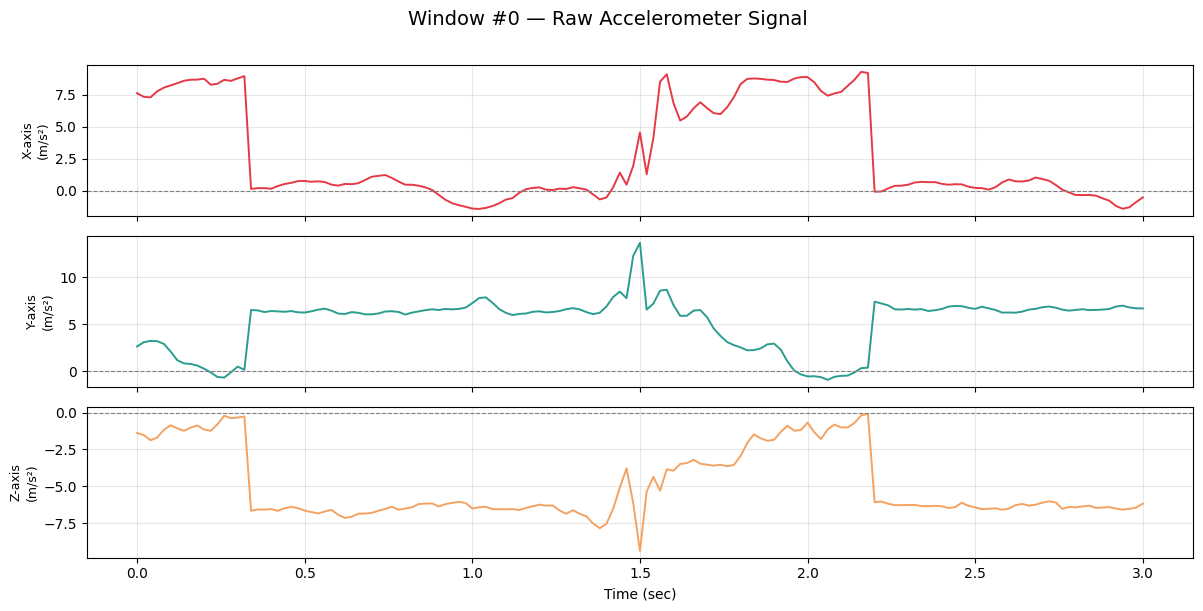

Saved → window_signal.png


In [7]:
WINDOW_IDX = 0    # change to inspect a different window
t = np.arange(WINDOW_LEN) / ASSUMED_HZ   # time axis in seconds

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
fig.suptitle(f"Window #{WINDOW_IDX} — Raw Accelerometer Signal", fontsize=14, y=1.01)

colors = ["#E63946", "#2A9D8F", "#F4A261"]
labels = ["X-axis", "Y-axis", "Z-axis"]
segments = [X, Y, Z]

for ax, seg, color, label in zip(axes, segments, colors, labels):
    ax.plot(t, seg[WINDOW_IDX], color=color, lw=1.4)
    ax.set_ylabel(f"{label}\n(m/s²)", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.8, ls="--")

axes[-1].set_xlabel("Time (sec)")
plt.tight_layout()
plt.savefig("window_signal.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → window_signal.png")

C:\Users\HC\AppData\Local\Temp\ipykernel_19088\2996864724.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=["X", "Y", "Z"],


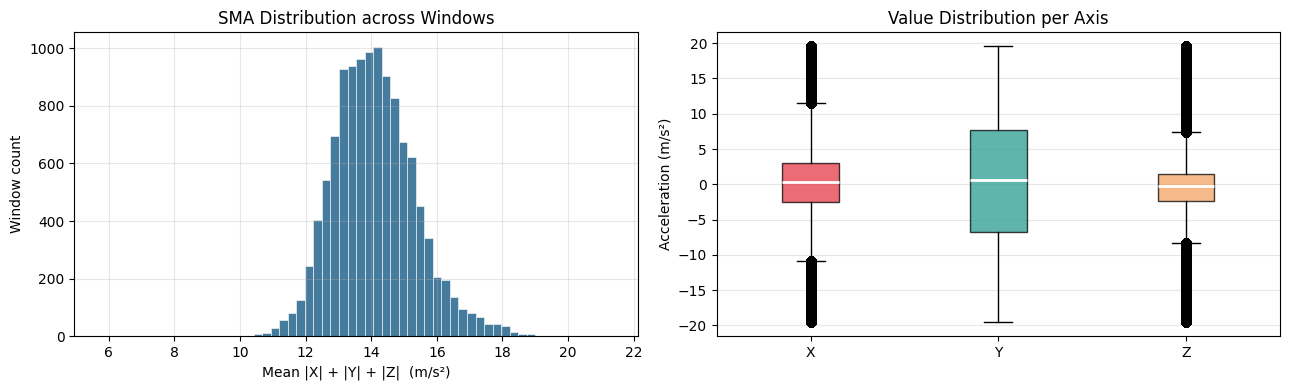

Saved → sma_distribution.png


In [8]:
# Signal Magnitude Area — commonly used HAR feature
SMA = (np.abs(X) + np.abs(Y) + np.abs(Z)).mean(axis=1)   # shape (N_WINDOWS,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
ax1.hist(SMA, bins=60, color="#457B9D", edgecolor="white", linewidth=0.4)
ax1.set_title("SMA Distribution across Windows", fontsize=12)
ax1.set_xlabel("Mean |X| + |Y| + |Z|  (m/s²)")
ax1.set_ylabel("Window count")
ax1.grid(True, alpha=0.3)

# Box plot per axis
box_data = [X.flatten(), Y.flatten(), Z.flatten()]
bp = ax2.boxplot(box_data, labels=["X", "Y", "Z"],
                 patch_artist=True, notch=False,
                 medianprops=dict(color="white", lw=2))
for patch, color in zip(bp["boxes"], ["#E63946", "#2A9D8F", "#F4A261"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_title("Value Distribution per Axis", fontsize=12)
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("sma_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sma_distribution.png")

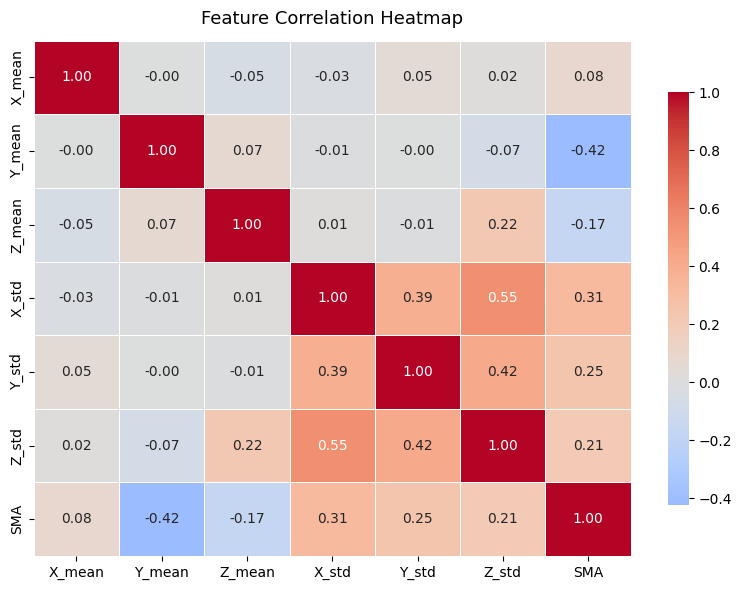

Saved → correlation_heatmap.png


In [9]:
# Compute simple per-window features for correlation analysis
features = pd.DataFrame({
    "X_mean" : X.mean(axis=1),
    "Y_mean" : Y.mean(axis=1),
    "Z_mean" : Z.mean(axis=1),
    "X_std"  : X.std(axis=1),
    "Y_std"  : Y.std(axis=1),
    "Z_std"  : Z.std(axis=1),
    "SMA"    : SMA,
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    features.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Heatmap", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → correlation_heatmap.png")

In [10]:
print()
print("╔" + "═" * 53 + "╗")
print("║      ACCELEROMETER DATASET — METADATA CARD       ║")
print("╠" + "═" * 53 + "╣")
rows = [
    ("No. of Subjects",  "Not specified"),
    ("Activities",       "Not specified"),
    ("Sensors Used",     "Accelerometer (3-axis)"),
    ("Sensor Placement", "Not specified"),
    ("Data Rate (Hz)",   f"Not specified (assumed {ASSUMED_HZ} Hz)"),
    ("Window Size",      f"{WINDOW_LEN} samples, ~{WINDOW_SEC:.2f} sec"),
    ("Overlap",          "Not specified"),
    ("Total Windows",    f"{N_WINDOWS:,}"),
    ("Feature Columns",  f"{N_FEATURES}  (3 axes × {WINDOW_LEN} steps)"),
    ("Value Range",      f"[{data.min():.3f}, {data.max():.3f}] m/s²"),
    ("Missing Values",   "None"),
]
for k, v in rows:
    line = f"  {k:<22}: {v}"
    print(f"║{line:<53}║")
print("╚" + "═" * 53 + "╝")


╔═════════════════════════════════════════════════════╗
║      ACCELEROMETER DATASET — METADATA CARD       ║
╠═════════════════════════════════════════════════════╣
║  No. of Subjects       : Not specified              ║
║  Activities            : Not specified              ║
║  Sensors Used          : Accelerometer (3-axis)     ║
║  Sensor Placement      : Not specified              ║
║  Data Rate (Hz)        : Not specified (assumed 50 Hz)║
║  Window Size           : 151 samples, ~3.02 sec     ║
║  Overlap               : Not specified              ║
║  Total Windows         : 11,771                     ║
║  Feature Columns       : 453  (3 axes × 151 steps)  ║
║  Value Range           : [-19.581, 19.581] m/s²     ║
║  Missing Values        : None                       ║
╚═════════════════════════════════════════════════════╝
